# Coffee Quality prediction

Using an imbalanced dataset with 86% specialty and 14% below-specialty coffee samples, I will train several binary classification models to identify below-specialty coffees (class 1). 
The model selection will be done through F_beta score, prioritizing precision over recall.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report
from data_train import cup_score_class, train_logistic_regression, evaluate_at_seed
from data_train import train_random_forest, train_xgb_model, plot_precision_recall_vs_threshold, choose_threshold
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

RANDOM_STATE = 42
BETA = 0.6
project_root = Path.cwd().parent

%load_ext autoreload
%autoreload 2

# Dataset

We have 1296 coffee samples with 8 selected features: variety, processing_method, moisture, defect counts, color, and altitude.
The target variable is `Total.Cup.Points`.

In [2]:
coffe_data_path = project_root / "data" / "cleaned_coffee_data.csv"   
df = pd.read_csv(coffe_data_path)
X = df.drop(columns= "Total.Cup.Points").copy()
y = df["Total.Cup.Points"].copy()
y = y.apply(cup_score_class)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
X.head()

X shape: (1296, 8)
y shape: (1296,)


,altitude_mean_meters,Moisture,Category.One.Defects,Category.Two.Defects,Quakers,Variety,Processing.Method,Color
0,2075.0,0.12,0,0,0.0,NaN,Washed / Wet,Green
1,2075.0,0.12,0,1,0.0,Other,Washed / Wet,Green
2,1700.0,0.00,0,0,0.0,Bourbon,NaN,NaN
3,2000.0,0.11,0,2,0.0,NaN,Natural / Dry,Green
4,2075.0,0.12,0,2,0.0,Other,Washed / Wet,Green


Total.Cup.Points
0    1118
1     178
Name: count, dtype: int64

Percentages:
Total.Cup.Points
0    86.3
1    13.7
Name: proportion, dtype: float64


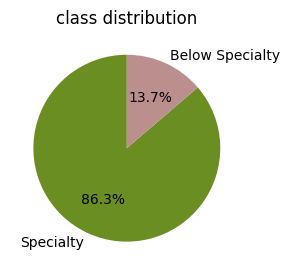

In [3]:
print(y.value_counts())
print(f"\nPercentages:")
print((y.value_counts(normalize=True)*100).round(1))

class_counts = y.value_counts()
plt.figure(figsize=(3, 3))
plt.pie(class_counts,labels=["Specialty", "Below Specialty",], autopct='%1.1f%%', 
    startangle=90,colors = ['olivedrab', 'rosybrown'])
plt.title("class distribution")
plt.tight_layout()
plt.show()

# Splitting the Dataset

To preserve the same ratio (Specialty/Below Specialty) in both datasets, we perform a stratified splitting using 'stratify =y'. 

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, 
                            random_state=RANDOM_STATE, stratify =y)
print(f"tran sample: {X_train.shape}, test samples: {X_test.shape}")

tran sample: (1036, 8), test samples: (260, 8)


## Feature Engineering

To fill the missing values in some of the features, we employed three strategies. For the numerical features: altitude_mean_meters and Moisture, we replaced the missing values with the median because it is robust for skewed distributions. Defect counts are filled with 0 since a missing defect most likely means no defects were recorded. Finally, categorical nulls become 'Unknown', preserving missingness as a category rather than discarding those rows. 
max_categories=10 was set on the OneHotEncoder to prevent high dimensionality due to the 'Variety' feature  that has 28 unique values.

In [5]:

median_num_features = ["altitude_mean_meters", "Moisture"]
zero_num_features = ["Category.One.Defects", "Category.Two.Defects", "Quakers"]
categorical_features = ["Variety", "Processing.Method", "Color"]

median_numerical_pipeline = Pipeline([
    ("impute_median", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

zero_numerical_pipeline = Pipeline([
    ("impute_zero", SimpleImputer(strategy="constant", fill_value=0)),
    ("scale", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("impute_unknown", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=False,max_categories=10)),
])

preprocessor = ColumnTransformer([
    ("num_median", median_numerical_pipeline, median_num_features),
    ("num_zero", zero_numerical_pipeline, zero_num_features),
    ("categorical", categorical_pipeline, categorical_features )
])

# Model building

The results shown below for each model belong to a single fixed train/test split. Since the below-specialty class has very few samples and considering that the non-sensory features only correlate weakly with the cupping score, the model's performance metrics on a given split would be a bit noisy. At the end of the notebook, we check the split sensitivity, re-running the same pipelines across 20 different splits to see how stable these results actually are.


## Logistic Regression 

For Logistic Regression we apply hyperparameter tuning to search for the optimal regularization parameter C to avoid overfitting. 

In [6]:
param_grid = {'lr__C': [0.001, 0.01, 0.05, 0.1, 1]}

best_lr_grid = train_logistic_regression(preprocessor, X_train, y_train,random_state=RANDOM_STATE,param_grid=param_grid)
print(f"Best grid parameters: {best_lr_grid.best_params_}")

lr_model = best_lr_grid.best_estimator_
y_test_pred_lr = lr_model.predict(X_test)
print(confusion_matrix(y_test, y_test_pred_lr))
print(classification_report(y_test, y_test_pred_lr, target_names=['Specialty (0)', 'Below Specialty (1)'],digits=3))

Best grid parameters: {'lr__C': 0.05}
[[167  57]
 [ 14  22]]
                     precision    recall  f1-score   support

      Specialty (0)      0.923     0.746     0.825       224
Below Specialty (1)      0.278     0.611     0.383        36

           accuracy                          0.727       260
          macro avg      0.601     0.678     0.604       260
       weighted avg      0.833     0.727     0.763       260



At the default 0.5 decision threshold, precision on the below-specialty is only ~0.28, meaning when the model predicts a coffee as below specialty it is right only 28% of the time, while the remaining 70% of those predictions are false positives that missclasify actual specialty coffee. A model like this, would inform wrongly the right coffee quality and make the farmers under-sell their coffe. To increase precision and reduce recall, this could be done by tuning the decision threshold.

## Precision and recall vs Threshold

To make a final decision, the model uses a classification threshold (by default set to 0.5). If the probability is above the threshold, it predicts class 1; if it is below, it predicts class 0. Accordingly, precision and recall will be defined based on the threshold values. By moving the threshold up or down, we can directly control the balance between precision and recall. 

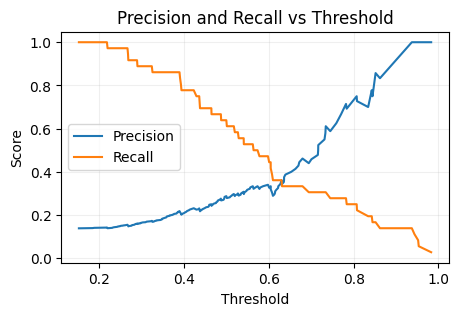

In [7]:
y_test_probs = lr_model.predict_proba(X_test)[:, 1]
plot_precision_recall_vs_threshold(y_test, y_test_probs)

# Threshold tuning

Threshold selection  will be done via cross_validation on the training set and by picking the
threshold that maximises F-beta score. We will use a F-beta value < 1, giving priority to precision over recall.

In [8]:

best_t, fbeta = choose_threshold(lr_model, X_train, y_train, beta= BETA, random_state=RANDOM_STATE)
print(f"Chosen threshold: {best_t:.3f}  (F(beta=0.5) = {fbeta:.3f})")

y_test_pred_lr = (lr_model.predict_proba(X_test)[:, 1] >= best_t).astype(int)
print(confusion_matrix(y_test, y_test_pred_lr))
print(classification_report(y_test, y_test_pred_lr, target_names=['Specialty (0)', 'Below Specialty (1)'],digits=3))

Chosen threshold: 0.660  (F(beta=0.5) = 0.358)
[[207  17]
 [ 24  12]]
                     precision    recall  f1-score   support

      Specialty (0)      0.896     0.924     0.910       224
Below Specialty (1)      0.414     0.333     0.369        36

           accuracy                          0.842       260
          macro avg      0.655     0.629     0.640       260
       weighted avg      0.829     0.842     0.835       260



# Random Forest Classifier



In [9]:

param_grid = {
        "rf__n_estimators": [100, 200, 300],
        "rf__max_features": ['sqrt', 0.3, 0.5],
        "rf__min_samples_leaf": [2, 3, 5, 7],
        "rf__max_depth": [None, 2, 3],
    }

rf_grid_search = train_random_forest(preprocessor, X_train, y_train, 
                                random_state=RANDOM_STATE, class_weight = 'balanced',param_grid=param_grid)
print(f"Best grid parameters: {rf_grid_search.best_params_}")
rf_model = rf_grid_search.best_estimator_

best_t, fbeta = choose_threshold(rf_model, X_train, y_train, beta= BETA, random_state=RANDOM_STATE)
print(f"Chosen threshold: {best_t:.3f}  (F(beta=0.5) = {fbeta:.3f})")

y_test_pred_rf = (rf_model.predict_proba(X_test)[:, 1] >= best_t).astype(int)

print(confusion_matrix(y_test, y_test_pred_rf))
print(classification_report(y_test, y_test_pred_rf, target_names=['Specialty (0)', 'Below Specialty (1)'],digits=3))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best grid parameters: {'rf__max_depth': None, 'rf__max_features': 0.3, 'rf__min_samples_leaf': 7, 'rf__n_estimators': 300}
Chosen threshold: 0.625  (F(beta=0.5) = 0.442)
[[204  20]
 [ 17  19]]
                     precision    recall  f1-score   support

      Specialty (0)      0.923     0.911     0.917       224
Below Specialty (1)      0.487     0.528     0.507        36

           accuracy                          0.858       260
          macro avg      0.705     0.719     0.712       260
       weighted avg      0.863     0.858     0.860       260



# XGBoost Classifier



In [11]:
param_grid = {
    'xgb__n_estimators': [30, 50, 70, 90],
    'xgb__max_depth': [2, 3, 4, 5, 6],
    'xgb__min_child_weight': [7, 9, 11, 13, 15]
}

grid_xgb = train_xgb_model(preprocessor, X_train, y_train, scoring='average_precision', 
                    random_state=RANDOM_STATE, param_grid=param_grid)

xgb_model = grid_xgb.best_estimator_
print(f"Best XGBoost Parameters: {grid_xgb.best_params_}")
best_t, fbeta = choose_threshold(xgb_model, X_train, y_train, beta= BETA, random_state=RANDOM_STATE)
print(f"Chosen threshold: {best_t:.3f}  (F(beta=0.5) = {fbeta:.3f})")

y_test_pred_xgb = (xgb_model.predict_proba(X_test)[:, 1] >= best_t).astype(int)

print(confusion_matrix(y_test, y_test_pred_xgb))
print(classification_report(y_test, y_test_pred_xgb, target_names=['Specialty (0)', 'Below Specialty (1)'],digits=3))

Best XGBoost Parameters: {'xgb__max_depth': 4, 'xgb__min_child_weight': 9, 'xgb__n_estimators': 30}
Chosen threshold: 0.690  (F(beta=0.5) = 0.450)
[[205  19]
 [ 22  14]]
                     precision    recall  f1-score   support

      Specialty (0)      0.903     0.915     0.909       224
Below Specialty (1)      0.424     0.389     0.406        36

           accuracy                          0.842       260
          macro avg      0.664     0.652     0.657       260
       weighted avg      0.837     0.842     0.839       260



## Checking split sensitivity

In [43]:
seeds = range(20)
all_rows = [row for s in seeds for row in evaluate_at_seed(s, X, y, preprocessor, beta=BETA)]
results_df = pd.DataFrame(all_rows)
summary = results_df.groupby("model")[["precision_1", "recall_1", "fbeta_1", "macro_f1"]].agg(["mean", "std"])
print(summary)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 5



Without threshold tuning, all models struggle to identify below-specialty coffee, which is expected given the class imbalance. However, across 20 train/test splits and including threshold-tuning that favors precision over recall, Random Forest shows to be the more robust model. While XGBoost also achieves comparable average metrics, Random Forest gives a high and more stable precision for class 1 and a high macro F1 score.
| Model | Precision (class 1) | Recall (class 1) | F1 Macro |
|---|---|---|---|
| Logistic Regression | 0.401  ± 0.081 | 0.246 ± 0.114 |  0.598 ± 0.042  |
| Random Forest       | 0.458  ± 0.075 | 0.318 ± 0.101  | 0.639 ± 0.030  |
| XGBoost             |  0.464 ± 0.149| 0.332 ± 0.120 | 0.640 ± 0.047 |

Having more below-specialty data would definitely improve the model's performance.